In [3]:
from src.data.freihand import FreiHand

dataset = FreiHand()
dataset.validate()
dataset.root

WindowsPath('C:/Users/victo/PycharmProjects/hand-pose-estimation/data/FreiHAND_pub_v2')

(224, 224, 3)
(21, 2)


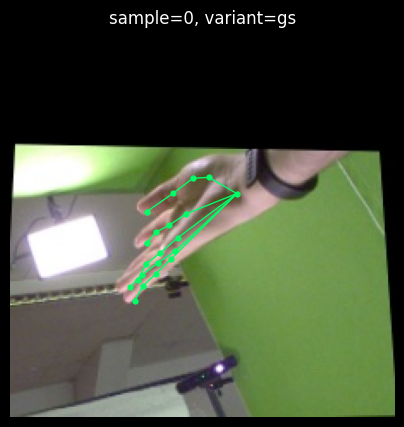

In [8]:
sample = dataset.sample(0, load_image=True)
print(sample.image.shape)
print(sample.keypoints.shape)

dataset.plot_sample(0, variant="gs");

In [5]:
images, keypoints = dataset.load_batch(range(8), image_size=(128, 128))
print(images.shape)
print(keypoints.shape)

(8, 128, 128, 3)
(8, 21, 2)


In [6]:
train_indices, val_indices = dataset.train_validation_split(validation_fraction=0.1, seed=42)

train_ds = dataset.tf_dataset(
    indices=train_indices[:512],
    batch_size=16,
    image_size=(128, 128),
    shuffle=True,
)

batch_images, batch_keypoints = next(iter(train_ds.take(1)))
print(batch_images.shape)
print(batch_keypoints.shape)

(16, 128, 128, 3)
(16, 21, 2)


In [7]:
sequence = dataset.keras_sequence(
    indices=train_indices[:128],
    batch_size=16,
    image_size=128,
)

batch_images, batch_keypoints = sequence[0]
print(batch_images.shape)
print(batch_keypoints.shape)

(16, 128, 128, 3)
(16, 21, 2)
